In [1]:
import time

import kagglehub

print("⏳ Downloading PaySim dataset...")
print("   This may take a few minutes depending on your connection.")

start_time = time.time()

path = kagglehub.dataset_download("ealaxi/paysim1")

elapsed = time.time() - start_time

print("✅ Download complete!")
print(f"📁 Dataset path: {path}")
print(f"⏱️ Download time: {elapsed:.1f} seconds")

⏳ Downloading PaySim dataset...
   This may take a few minutes depending on your connection.
✅ Download complete!
📁 Dataset path: /home/dawit-abraham/.cache/kagglehub/datasets/ealaxi/paysim1/versions/2
⏱️ Download time: 1.4 seconds


In [2]:
import os

import numpy as np
import pandas as pd

filename = os.listdir(path)[0]
file_path = os.path.join(path, filename)
df = pd.read_csv(file_path)

In [3]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [6]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [7]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


Amount sanity check

In [10]:
print("Zero amount:", (df["amount"] == 0).sum())
print("Negative amount:", (df["amount"] < 0).sum())
print("Minimum amount:", df["amount"].min())

Zero amount: 16
Negative amount: 0
Minimum amount: 0.0


In [11]:
zero_amount_stats = (
    df.groupby(df["amount"] == 0)["isFraud"]
    .agg(
        transactions="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

zero_amount_stats["fraud_rate"] *= 100

zero_amount_stats

,transactions,fraud_count,fraud_rate
amount,,,
False,6362604,8197,0.128831
True,16,16,100.000000


outlier × fraud analysis

In [12]:
overall_fraud_rate = df["isFraud"].mean() * 100

print(f"Overall fraud rate: {overall_fraud_rate:.4f}%")

Overall fraud rate: 0.1291%


In [13]:
numeric_features = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]



In [14]:
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)

IQR = Q3 - Q1

outlier_mask = (
    (df[numeric_features] < (Q1 - 1.5 * IQR)) |
    (df[numeric_features] > (Q3 + 1.5 * IQR))
)

df["is_outlier"] = outlier_mask.any(axis=1)

outlier_fraud = (
    df.groupby("is_outlier")["isFraud"]
      .agg(
          transactions="count",
          fraud_count="sum",
          fraud_rate="mean"
      )
)

outlier_fraud["fraud_rate"] *= 100

outlier_fraud

,transactions,fraud_count,fraud_rate
is_outlier,,,
False,4393187,3064,0.069744
True,1969433,5149,0.261446


In [15]:
class_stats = (
    df["isFraud"]
    .value_counts()
    .rename_axis("isFraud")
    .reset_index(name="transactions")
)

class_stats["percentage"] = (
    class_stats["transactions"] / len(df) * 100
)

class_stats

,isFraud,transactions,percentage
0,0,6354407,99.870918
1,1,8213,0.129082


In [16]:
print(f"Fraud rate: {df['isFraud'].mean() * 100:.4f}%")

Fraud rate: 0.1291%


In [17]:
type_stats = (
    df.groupby("type")["isFraud"]
    .agg(
        transactions="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

type_stats["fraud_rate"] *= 100

type_stats.sort_values("fraud_rate", ascending=False)

,transactions,fraud_count,fraud_rate
type,,,
TRANSFER,532909,4097,0.768799
CASH_OUT,2237500,4116,0.183955
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


In [18]:
df[df["isFraud"] == 1]["type"].value_counts()

type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64

# Balance behavior

In [19]:
df["orig_balance_change"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"]
)

df["dest_balance_change"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

In [20]:
balance_features = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "orig_balance_change",
    "dest_balance_change"
]

balance_stats = (
    df.groupby("isFraud")[balance_features]
    .mean()
    .T
)

balance_stats.columns = ["Legitimate", "Fraud"]

balance_stats

,Legitimate,Fraud
amount,1.781970e+05,1.467967e+06
oldbalanceOrg,8.328287e+05,1.649668e+06
newbalanceOrig,8.559702e+05,1.923926e+05
oldbalanceDest,1.101421e+06,5.442496e+05
newbalanceDest,1.224926e+06,1.279708e+06
orig_balance_change,-2.314152e+04,1.457275e+06
dest_balance_change,1.235048e+05,7.354580e+05


In [21]:
df["orig_balance_error"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
)

df["dest_balance_error"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
)

In [22]:
df.groupby("isFraud")[
    ["orig_balance_error", "dest_balance_error"]
].describe()

orig_balance_error                                             \
                     count           mean            std          min   
isFraud                                                                 
0                6354407.0 -201338.558109  606928.890826 -92445516.64   
1                   8213.0  -10692.325265  265146.131130 -10000000.00   

                                                     dest_balance_error  \
               25%       50%       75%           max              count   
isFraud                                                                   
0       -249953.43 -69049.31 -3034.305  1.000000e-02          6354407.0   
1             0.00      0.00     0.000  3.725290e-09             8213.0   

                                                                             \
                  mean           std          min  25%      50%         75%   
isFraud                                                                       
0         54692.231734  4.360026e+05 -75885725.63  0.0  3500.68   29259.805   
1        732509.301069  1.867748e+06  -8875516.29  0.0  2231.46  442722.010   

                      
                 max  
isFraud               
0        13191233.98  
1        10000000.00

In [23]:
flagged_stats = (
    df.groupby("isFlaggedFraud")["isFraud"]
    .agg(
        transactions="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

flagged_stats["fraud_rate"] *= 100

flagged_stats

,transactions,fraud_count,fraud_rate
isFlaggedFraud,,,
0,6362604,8197,0.128831
1,16,16,100.000000


In [24]:
pd.crosstab(
    df["isFlaggedFraud"],
    df["isFraud"],
    margins=True
)

isFraud,0,1,All
isFlaggedFraud,,,
0,6354407,8197,6362604
1,0,16,16
All,6354407,8213,6362620


In [25]:
numeric_features = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "orig_balance_change",
    "dest_balance_change",
    "orig_balance_error",
    "dest_balance_error"
]

In [26]:
grouped = df.groupby("isFraud")[numeric_features].agg(["mean", "std"])

mean_0 = grouped.loc[0].xs("mean", level=1)
mean_1 = grouped.loc[1].xs("mean", level=1)

std_0 = grouped.loc[0].xs("std", level=1)
std_1 = grouped.loc[1].xs("std", level=1)

smd = (
    (mean_1 - mean_0)
    / np.sqrt((std_1**2 + std_0**2) / 2)
)

feature_effects = pd.DataFrame({
    "Mean_Legitimate": mean_0,
    "Mean_Fraud": mean_1,
    "SMD": smd,
    "Abs_SMD": smd.abs()
}).sort_values("Abs_SMD", ascending=False)

feature_effects

,Mean_Legitimate,Mean_Fraud,SMD,Abs_SMD
orig_balance_change,-2.314152e+04,1.457275e+06,0.872907,0.872907
amount,1.781970e+05,1.467967e+06,0.736355,0.736355
dest_balance_error,5.469223e+04,7.325093e+05,0.499790,0.499790
dest_balance_change,1.235048e+05,7.354580e+05,0.427137,0.427137
orig_balance_error,-2.013386e+05,-1.069233e+04,0.407077,0.407077
newbalanceOrig,8.559702e+05,1.923926e+05,-0.266291,0.266291
oldbalanceOrg,8.328287e+05,1.649668e+06,0.252552,0.252552
oldbalanceDest,1.101421e+06,5.442496e+05,-0.165433,0.165433
newbalanceDest,1.224926e+06,1.279708e+06,0.014442,0.014442


In [27]:
from scipy.stats import ks_2samp

ks_results = []

for feature in numeric_features:
    legit = df.loc[df["isFraud"] == 0, feature]
    fraud = df.loc[df["isFraud"] == 1, feature]

    statistic, p_value = ks_2samp(legit, fraud)

    ks_results.append({
        "Feature": feature,
        "KS_Statistic": statistic,
        "p_value": p_value
    })

ks_results = pd.DataFrame(ks_results)

ks_results.sort_values(
    "KS_Statistic",
    ascending=False
)

,Feature,KS_Statistic,p_value
7,orig_balance_error,0.808392,0.000000e+00
5,orig_balance_change,0.804171,0.000000e+00
1,oldbalanceOrg,0.542525,0.000000e+00
0,amount,0.444136,0.000000e+00
2,newbalanceOrig,0.413745,0.000000e+00
3,oldbalanceDest,0.244726,0.000000e+00
8,dest_balance_error,0.228860,0.000000e+00
6,dest_balance_change,0.191670,2.239402e-264
4,newbalanceDest,0.115234,2.445360e-95


In [28]:
corr_matrix = df[numeric_features + ["isFraud"]].corr()

target_corr = (
    corr_matrix["isFraud"]
    .drop("isFraud")
    .sort_values(key=abs, ascending=False)
)

target_corr

orig_balance_change    0.362472
amount                 0.076688
dest_balance_error     0.055120
dest_balance_change    0.027028
orig_balance_error     0.011283
oldbalanceOrg          0.010154
newbalanceOrig        -0.008148
oldbalanceDest        -0.005885
newbalanceDest         0.000535
Name: isFraud, dtype: float64

In [29]:
feature_corr = df[numeric_features].corr()

feature_corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_change,dest_balance_change,orig_balance_error,dest_balance_error
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.102337,0.845964,-0.970660,-0.189928
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,-0.220297,-0.087032,-0.050502,0.156464
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.267750,-0.094456,-0.056897,0.163161
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.047460,0.232316,-0.304256,-0.025460
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,-0.006451,0.436191,-0.458750,-0.174942
orig_balance_change,0.102337,-0.220297,-0.267750,-0.047460,-0.006451,1.000000,0.169292,0.139860,-0.171737
dest_balance_change,0.845964,-0.087032,-0.094456,0.232316,0.436191,0.169292,1.000000,-0.801148,-0.684207
orig_balance_error,-0.970660,-0.050502,-0.056897,-0.304256,-0.458750,0.139860,-0.801148,1.000000,0.147540
dest_balance_error,-0.189928,0.156464,0.163161,-0.025460,-0.174942,-0.171737,-0.684207,0.147540,1.000000


In [30]:
df[numeric_features].skew().sort_values(ascending=False)

dest_balance_change    32.916341
amount                 30.993949
orig_balance_change    24.630520
oldbalanceDest         19.921758
newbalanceDest         19.352302
oldbalanceOrg           5.249136
newbalanceOrig          5.176884
orig_balance_error    -30.074746
dest_balance_error    -49.202276
dtype: float64

In [31]:
fraud_by_step = (
    df.groupby("step")["isFraud"]
    .agg(
        transactions="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

fraud_by_step["fraud_rate"] *= 100

fraud_by_step.head()

,transactions,fraud_count,fraud_rate
step,,,
1,2708,16,0.590842
2,1014,8,0.788955
3,552,4,0.724638
4,565,10,1.769912
5,665,6,0.902256


In [32]:
fraud_by_step.sort_values(
    "fraud_rate",
    ascending=False
).head(20)

,transactions,fraud_count,fraud_rate
step,,,
727,12,12,100.0
743,8,8,100.0
742,14,14,100.0
410,20,20,100.0
411,16,16,100.0
412,8,8,100.0
414,16,16,100.0
415,16,16,100.0
417,6,6,100.0


In [33]:
df["orig_transaction_count"] = (
    df.groupby("nameOrig")["nameOrig"]
    .transform("count")
)

df["orig_total_amount"] = (
    df.groupby("nameOrig")["amount"]
    .transform("sum")
)

df["orig_avg_amount"] = (
    df.groupby("nameOrig")["amount"]
    .transform("mean")
)

In [34]:
df["dest_transaction_count"] = (
    df.groupby("nameDest")["nameDest"]
    .transform("count")
)

df["dest_total_amount"] = (
    df.groupby("nameDest")["amount"]
    .transform("sum")
)

df["dest_avg_amount"] = (
    df.groupby("nameDest")["amount"]
    .transform("mean")
)

In [35]:
account_features = [
    "orig_transaction_count",
    "orig_total_amount",
    "orig_avg_amount",
    "dest_transaction_count",
    "dest_total_amount",
    "dest_avg_amount"
]

account_behavior = (
    df.groupby("isFraud")[account_features]
    .mean()
    .T
)

account_behavior.columns = [
    "Legitimate",
    "Fraud"
]

account_behavior

,Legitimate,Fraud
orig_transaction_count,1.002932e+00,1.003409e+00
orig_total_amount,1.787340e+05,1.468447e+06
orig_avg_amount,1.781991e+05,1.466394e+06
dest_transaction_count,1.119624e+01,8.095337e+00
dest_total_amount,3.198327e+06,3.556984e+06
dest_avg_amount,1.790205e+05,8.308296e+05


In [36]:
df["hour_of_day"] = df["step"] % 24
type_time = (
    df.groupby(["hour_of_day", "type"])["isFraud"]
    .agg(
        transactions="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
    .reset_index()
)

type_time["fraud_rate"] *= 100

type_time

,hour_of_day,type,transactions,fraud_count,fraud_rate
0,0,CASH_IN,11170,0,0.000000
1,0,CASH_OUT,11997,150,1.250313
2,0,DEBIT,1647,0,0.000000
3,0,PAYMENT,40556,0,0.000000
4,0,TRANSFER,6217,150,2.412739
...,...,...,...,...,...
115,23,CASH_IN,23805,0,0.000000
116,23,CASH_OUT,26168,161,0.615255
117,23,DEBIT,2073,0,0.000000
118,23,PAYMENT,77345,0,0.000000


# SMD

In [37]:
grouped = df.groupby("isFraud")[numeric_features].agg(["mean", "std"])

mean_0 = grouped.loc[0].xs("mean", level=1)
mean_1 = grouped.loc[1].xs("mean", level=1)

std_0 = grouped.loc[0].xs("std", level=1)
std_1 = grouped.loc[1].xs("std", level=1)

smd = (
    (mean_1 - mean_0)
    / np.sqrt((std_1**2 + std_0**2) / 2)
)

feature_separation = pd.DataFrame({
    "Legitimate_Mean": mean_0,
    "Fraud_Mean": mean_1,
    "SMD": smd,
    "Abs_SMD": smd.abs()
}).sort_values("Abs_SMD", ascending=False)

feature_separation

,Legitimate_Mean,Fraud_Mean,SMD,Abs_SMD
orig_balance_change,-2.314152e+04,1.457275e+06,0.872907,0.872907
amount,1.781970e+05,1.467967e+06,0.736355,0.736355
dest_balance_error,5.469223e+04,7.325093e+05,0.499790,0.499790
dest_balance_change,1.235048e+05,7.354580e+05,0.427137,0.427137
orig_balance_error,-2.013386e+05,-1.069233e+04,0.407077,0.407077
newbalanceOrig,8.559702e+05,1.923926e+05,-0.266291,0.266291
oldbalanceOrg,8.328287e+05,1.649668e+06,0.252552,0.252552
oldbalanceDest,1.101421e+06,5.442496e+05,-0.165433,0.165433
newbalanceDest,1.224926e+06,1.279708e+06,0.014442,0.014442


# KS test

In [38]:
from scipy.stats import ks_2samp

ks_results = []

for feature in numeric_features:
    legitimate = df.loc[df["isFraud"] == 0, feature]
    fraud = df.loc[df["isFraud"] == 1, feature]

    statistic, p_value = ks_2samp(legitimate, fraud)

    ks_results.append({
        "Feature": feature,
        "KS_Statistic": statistic,
        "p_value": p_value
    })

ks_results = (
    pd.DataFrame(ks_results)
    .sort_values("KS_Statistic", ascending=False)
)

ks_results

,Feature,KS_Statistic,p_value
7,orig_balance_error,0.808392,0.000000e+00
5,orig_balance_change,0.804171,0.000000e+00
1,oldbalanceOrg,0.542525,0.000000e+00
0,amount,0.444136,0.000000e+00
2,newbalanceOrig,0.413745,0.000000e+00
3,oldbalanceDest,0.244726,0.000000e+00
8,dest_balance_error,0.228860,0.000000e+00
6,dest_balance_change,0.191670,2.239402e-264
4,newbalanceDest,0.115234,2.445360e-95


# Correlation

In [39]:
correlation = (
    df[numeric_features + ["isFraud"]]
    .corr()["isFraud"]
    .drop("isFraud")
    .sort_values(key=abs, ascending=False)
)

correlation

orig_balance_change    0.362472
amount                 0.076688
dest_balance_error     0.055120
dest_balance_change    0.027028
orig_balance_error     0.011283
oldbalanceOrg          0.010154
newbalanceOrig        -0.008148
oldbalanceDest        -0.005885
newbalanceDest         0.000535
Name: isFraud, dtype: float64

In [40]:
df.groupby(["type", "isFraud"])[
    [
        "amount",
        "orig_balance_change",
        "orig_balance_error",
        "dest_balance_change",
        "dest_balance_error"
    ]
].mean()

amount  orig_balance_change  orig_balance_error  \
type     isFraud                                                          
CASH_IN  0        1.689202e+05        -1.689152e+05      -337835.445783   
CASH_OUT 0        1.739172e+05         2.592296e+04      -147994.192774   
         1        1.455103e+06         1.453796e+06        -1306.125231   
DEBIT    0        5.483665e+03         3.485685e+03        -1997.980151   
PAYMENT  0        1.305760e+04         6.378937e+03        -6678.667998   
TRANSFER 0        9.062290e+05         3.317839e+04      -873050.622427   
         1        1.480892e+06         1.460770e+06       -20122.054174   

                  dest_balance_change  dest_balance_error  
type     isFraud                                           
CASH_IN  0              -1.208134e+05        2.897337e+05  
CASH_OUT 0               1.912257e+05       -1.730854e+04  
         1               1.464626e+06       -9.523835e+03  
DEBIT    0               1.986770e+04       -1.438403e+04  
PAYMENT  0               0.000000e+00        1.305760e+04  
TRANSFER 0               9.945851e+05       -8.835610e+04  
         1               2.908027e+03        1.477984e+06

# feature engineering

In [41]:
model_df = df.copy()

model_df["hour_of_day"] = model_df["step"] % 24


# -------------------------
# Balance-flow features
# -------------------------

model_df["orig_balance_change"] = (
    model_df["oldbalanceOrg"] - model_df["newbalanceOrig"]
)

model_df["dest_balance_change"] = (
    model_df["newbalanceDest"] - model_df["oldbalanceDest"]
)

model_df["orig_balance_error"] = (
    model_df["oldbalanceOrg"]
    - model_df["amount"]
    - model_df["newbalanceOrig"]
)

model_df["dest_balance_error"] = (
    model_df["oldbalanceDest"]
    + model_df["amount"]
    - model_df["newbalanceDest"]
)

ratio features

In [42]:
# Avoid division by zero
model_df["amount_to_orig_balance"] = (
    model_df["amount"] /
    (model_df["oldbalanceOrg"] + 1)
)

model_df["amount_to_dest_balance"] = (
    model_df["amount"] /
    (model_df["oldbalanceDest"] + 1)
)


model_df["orig_balance_change_ratio"] = (
    model_df["orig_balance_change"] /
    (model_df["oldbalanceOrg"] + 1)
)

model_df["dest_balance_change_ratio"] = (
    model_df["dest_balance_change"] /
    (model_df["oldbalanceDest"] + 1)
)

In [43]:
model_df = pd.get_dummies(
    model_df,
    columns=["type"],
    dtype=int
)

In [44]:
drop_columns = [
    "nameOrig",
    "nameDest",
    "isFraud"
]

X = model_df.drop(columns=drop_columns)
y = model_df["isFraud"]

In [45]:
history_features = [
    "orig_transaction_count",
    "orig_total_amount",
    "orig_avg_amount",
    "dest_transaction_count",
    "dest_total_amount",
    "dest_avg_amount"
]

model_df = model_df.drop(
    columns=history_features + ["is_outlier"]
)

X = model_df.drop(columns=["nameOrig", "nameDest", "isFraud"])
y = model_df["isFraud"]


In [46]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (6362620, 21)
y shape: (6362620,)

Features:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'orig_balance_change', 'dest_balance_change', 'orig_balance_error', 'dest_balance_error', 'hour_of_day', 'amount_to_orig_balance', 'amount_to_dest_balance', 'orig_balance_change_ratio', 'dest_balance_change_ratio', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


Historical account behavior

In [47]:
df_history = df.copy()

df_history["original_index"] = df_history.index

df_history = df_history.sort_values(
    ["step", "original_index"]
)

In [48]:
df_history = df_history.sort_values("original_index")

In [49]:
df_history["orig_previous_transaction_count"] = (
    df_history.groupby("nameOrig").cumcount()
)

In [50]:
df_history["orig_previous_total_amount"] = (
    df_history.groupby("nameOrig")["amount"]
    .cumsum()
    - df_history["amount"]
)

In [51]:
df_history["orig_previous_avg_amount"] = (
    df_history["orig_previous_total_amount"]
    / df_history["orig_previous_transaction_count"].replace(0, np.nan)
)

df_history["orig_previous_avg_amount"] = (
    df_history["orig_previous_avg_amount"]
    .fillna(0)
)

Destination account history

In [52]:
df_history["dest_previous_transaction_count"] = (
    df_history.groupby("nameDest").cumcount()
)

df_history["dest_previous_total_amount"] = (
    df_history.groupby("nameDest")["amount"].cumsum()
    - df_history["amount"]
)

df_history["dest_previous_avg_amount"] = (
    df_history["dest_previous_total_amount"]
    / df_history["dest_previous_transaction_count"].replace(0, np.nan)
)

df_history["dest_previous_avg_amount"] = (
    df_history["dest_previous_avg_amount"].fillna(0)
)

In [53]:
df_history["orig_prev_step"] = (
    df_history.groupby("nameOrig")["step"].shift(1)
)

df_history["orig_time_since_previous"] = (
    df_history["step"] - df_history["orig_prev_step"]
).fillna(-1)

In [54]:
df_history["dest_prev_step"] = (
    df_history.groupby("nameDest")["step"].shift(1)
)

df_history["dest_time_since_previous"] = (
    df_history["step"] - df_history["dest_prev_step"]
).fillna(-1)

In [55]:
# ============================================================
# BUILD FINAL MODEL DATASET
# ============================================================

# Features that use the entire account history
# We DO NOT want these in the model.
leakage_features = [
    "orig_transaction_count",
    "orig_total_amount",
    "orig_avg_amount",
    "dest_transaction_count",
    "dest_total_amount",
    "dest_avg_amount"
]

# EDA-only feature
eda_only_features = [
    "is_outlier"
]

# Drop leakage/EDA features
model_df = df_history.drop(
    columns=leakage_features + eda_only_features
).copy()

# One-hot encode transaction type
model_df = pd.get_dummies(
    model_df,
    columns=["type"],
    dtype=int
)

# Columns that must not enter the model
drop_columns = [
    "nameOrig",
    "nameDest",
    "isFraud",
    "original_index",
    "orig_prev_step",
    "dest_prev_step"
]

X = model_df.drop(columns=drop_columns)
y = model_df["isFraud"]

# ============================================================
# FINAL CHECK
# ============================================================

print("=" * 60)
print("FINAL MODEL DATASET")
print("=" * 60)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", len(X.columns))

print("\nFeatures:")
for i, feature in enumerate(X.columns, 1):
    print(f"{i:2}. {feature}")

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)

print(X.dtypes.value_counts())

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

print("Total missing:", X.isna().sum().sum())

print("\n" + "=" * 60)
print("TARGET")
print("=" * 60)

print(y.value_counts())
print(f"\nFraud rate: {y.mean() * 100:.4f}%")

FINAL MODEL DATASET
X shape: (6362620, 25)
y shape: (6362620,)
Number of features: 25

Features:
 1. step
 2. amount
 3. oldbalanceOrg
 4. newbalanceOrig
 5. oldbalanceDest
 6. newbalanceDest
 7. isFlaggedFraud
 8. orig_balance_change
 9. dest_balance_change
10. orig_balance_error
11. dest_balance_error
12. hour_of_day
13. orig_previous_transaction_count
14. orig_previous_total_amount
15. orig_previous_avg_amount
16. dest_previous_transaction_count
17. dest_previous_total_amount
18. dest_previous_avg_amount
19. orig_time_since_previous
20. dest_time_since_previous
21. type_CASH_IN
22. type_CASH_OUT
23. type_DEBIT
24. type_PAYMENT
25. type_TRANSFER

DATA TYPES
float64    15
int64      10
Name: count, dtype: int64

MISSING VALUES
Total missing: 0

TARGET
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud rate: 0.1291%


In [56]:
# ============================================================
# TEMPORAL SPLIT BY COMPLETE TIME STEPS
# ============================================================

# X and y are already aligned
steps = X["step"]

# Get unique time steps in chronological order
unique_steps = sorted(steps.unique())

n_steps = len(unique_steps)

# 70% / 15% / 15% of TIME STEPS
train_step_end = int(n_steps * 0.70)
val_step_end = int(n_steps * 0.85)

train_steps = unique_steps[:train_step_end]
val_steps = unique_steps[train_step_end:val_step_end]
test_steps = unique_steps[val_step_end:]

# Create masks
train_mask = steps.isin(train_steps)
val_mask = steps.isin(val_steps)
test_mask = steps.isin(test_steps)

# Split
X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_val = X.loc[val_mask].copy()
y_val = y.loc[val_mask].copy()

X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

# ============================================================
# RESULTS
# ============================================================

print("=" * 60)
print("CHRONOLOGICAL SPLIT BY COMPLETE TIME STEPS")
print("=" * 60)

for name, X_part, y_part in [
    ("Train", X_train, y_train),
    ("Validation", X_val, y_val),
    ("Test", X_test, y_test)
]:
    print(
        f"{name:12} | "
        f"Transactions: {len(X_part):,} | "
        f"Fraud: {y_part.sum():,} | "
        f"Fraud rate: {y_part.mean() * 100:.4f}% | "
        f"Steps: {X_part['step'].min()} → {X_part['step'].max()}"
    )

# ============================================================
# VERIFY NO TIME-STEP OVERLAP
# ============================================================

print("\n" + "=" * 60)
print("TIME STEP OVERLAP CHECK")
print("=" * 60)

print("Train ∩ Validation:",
      len(set(X_train["step"]) & set(X_val["step"])))

print("Validation ∩ Test:",
      len(set(X_val["step"]) & set(X_test["step"])))

print("Train ∩ Test:",
      len(set(X_train["step"]) & set(X_test["step"])))

CHRONOLOGICAL SPLIT BY COMPLETE TIME STEPS
Train        | Transactions: 6,082,007 | Fraud: 5,781 | Fraud rate: 0.0951% | Steps: 1 → 520
Validation   | Transactions: 191,147 | Fraud: 1,180 | Fraud rate: 0.6173% | Steps: 521 → 631
Test         | Transactions: 89,466 | Fraud: 1,252 | Fraud rate: 1.3994% | Steps: 632 → 743

TIME STEP OVERLAP CHECK
Train ∩ Validation: 0
Validation ∩ Test: 0
Train ∩ Test: 0


In [57]:
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

# ============================================================
# STEP 3.2: BASELINE XGBOOST
# ============================================================

# Calculate class imbalance
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative samples:", f"{negative:,}")
print("Positive samples:", f"{positive:,}")
print("Scale pos weight:", round(scale_pos_weight, 2))

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

print("\nTraining XGBoost...")

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# ------------------------------------------------------------
# Validation predictions
# ------------------------------------------------------------

y_val_proba = model.predict_proba(X_val)[:, 1]

# Default threshold = 0.5
y_val_pred = (y_val_proba >= 0.5).astype(int)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

pr_auc = average_precision_score(
    y_val,
    y_val_proba
)

roc_auc = roc_auc_score(
    y_val,
    y_val_proba
)

precision = precision_score(
    y_val,
    y_val_pred,
    zero_division=0
)

recall = recall_score(
    y_val,
    y_val_pred,
    zero_division=0
)

f1 = f1_score(
    y_val,
    y_val_pred,
    zero_division=0
)

print("\n" + "=" * 60)
print("VALIDATION RESULTS")
print("=" * 60)

print(f"PR-AUC:   {pr_auc:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

Negative samples: 6,076,226
Positive samples: 5,781
Scale pos weight: 1051.07

Training XGBoost...
[0]	validation_0-aucpr:0.74915
[50]	validation_0-aucpr:1.00000
[100]	validation_0-aucpr:1.00000
[150]	validation_0-aucpr:1.00000
[200]	validation_0-aucpr:1.00000
[250]	validation_0-aucpr:1.00000
[299]	validation_0-aucpr:1.00000

VALIDATION RESULTS
PR-AUC:   1.0000
ROC-AUC:  1.0000
Precision: 1.0000
Recall:    1.0000
F1:        1.0000

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    189967
       Fraud       1.00      1.00      1.00      1180

    accuracy                           1.00    191147
   macro avg       1.00      1.00      1.00    191147
weighted avg       1.00      1.00      1.00    191147



In [58]:
# ============================================================
# LEAKAGE AUDIT
# ============================================================

print("=" * 60)
print("1. FEATURE IMPORTANCE")
print("=" * 60)

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.to_string(index=False))


print("\n" + "=" * 60)
print("2. FRAUD RATE BY TRANSACTION TYPE")
print("=" * 60)

type_columns = [
    "type_CASH_IN",
    "type_CASH_OUT",
    "type_DEBIT",
    "type_PAYMENT",
    "type_TRANSFER"
]

for col in type_columns:
    if col in X_val.columns:
        mask = X_val[col] == 1
        if mask.sum() > 0:
            print(
                f"{col:20} "
                f"transactions={mask.sum():,} "
                f"fraud={y_val[mask].sum():,} "
                f"rate={y_val[mask].mean()*100:.4f}%"
            )


print("\n" + "=" * 60)
print("3. FRAUD RATE BY KEY FEATURES")
print("=" * 60)

for feature in [
    "orig_balance_change",
    "orig_balance_error",
    "amount",
    "dest_balance_change",
    "dest_balance_error"
]:
    print(f"\n{feature}")
    print(
        X_val.assign(isFraud=y_val.values)
        .groupby("isFraud")[feature]
        .describe()[["mean", "std", "min", "50%", "max"]]
    )


print("\n" + "=" * 60)
print("4. CHECK FOR FEATURES THAT MAY DIRECTLY IDENTIFY FRAUD")
print("=" * 60)

for feature in X_train.columns:
    if X_train[feature].nunique() <= 20:
        grouped = (
            X_train.assign(isFraud=y_train.values)
            .groupby(feature)["isFraud"]
            .agg(["count", "sum", "mean"])
        )

        # Show suspicious cases where a feature value strongly
        # separates fraud from legitimate transactions
        suspicious = grouped[
            (grouped["count"] >= 100) &
            ((grouped["mean"] == 0) | (grouped["mean"] == 1))
        ]

        if len(suspicious) > 0:
            print(f"\nPotentially suspicious: {feature}")
            print(suspicious)

1. FEATURE IMPORTANCE
                        feature  importance
                 newbalanceOrig    0.289335
             orig_balance_error    0.221250
            orig_balance_change    0.220021
                   type_PAYMENT    0.156886
                         amount    0.032441
                  type_TRANSFER    0.012521
                  oldbalanceOrg    0.012013
                     type_DEBIT    0.008045
                  type_CASH_OUT    0.007040
                    hour_of_day    0.006127
             dest_balance_error    0.005998
                 newbalanceDest    0.005849
                 isFlaggedFraud    0.005727
                 oldbalanceDest    0.005570
            dest_balance_change    0.003025
                           step    0.002739
     dest_previous_total_amount    0.001941
       dest_previous_avg_amount    0.001673
       dest_time_since_previous    0.000928
dest_previous_transaction_count    0.000786
                   type_CASH_IN    0.000086
     orig_

In [59]:
# ============================================================
# STEP 3.3: FINAL TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predict fraud probabilities on the untouched test set
y_test_proba = model.predict_proba(X_test)[:, 1]

# Default threshold
y_test_pred = (y_test_proba >= 0.5).astype(int)

# Metrics
test_pr_auc = average_precision_score(
    y_test,
    y_test_proba
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

cm = confusion_matrix(y_test, y_test_pred)

print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(f"PR-AUC:    {test_pr_auc:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print(f"Precision:  {test_precision:.4f}")
print(f"Recall:     {test_recall:.4f}")
print(f"F1:         {test_f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

FINAL TEST RESULTS
PR-AUC:    1.0000
ROC-AUC:   1.0000
Precision:  1.0000
Recall:     1.0000
F1:         1.0000

Confusion Matrix:
[[88214     0]
 [    0  1252]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     88214
       Fraud       1.00      1.00      1.00      1252

    accuracy                           1.00     89466
   macro avg       1.00      1.00      1.00     89466
weighted avg       1.00      1.00      1.00     89466



In [60]:
# ============================================================
# FINAL FEATURE / TARGET LEAKAGE AUDIT
# ============================================================

print("=" * 70)
print("CORRELATION WITH TARGET")
print("=" * 70)

corr = (
    X_train.assign(isFraud=y_train)
    .corr(numeric_only=True)["isFraud"]
    .drop("isFraud")
    .abs()
    .sort_values(ascending=False)
)

print(corr)


print("\n" + "=" * 70)
print("UNIQUE VALUES IN IMPORTANT FEATURES")
print("=" * 70)

important_features = [
    "newbalanceOrig",
    "orig_balance_change",
    "orig_balance_error",
    "dest_balance_change",
    "dest_balance_error",
    "amount"
]

for feature in important_features:
    print(f"\n{feature}")
    print("Unique values:", X_train[feature].nunique())
    print("Min:", X_train[feature].min())
    print("Max:", X_train[feature].max())


print("\n" + "=" * 70)
print("DO ENGINEERED FEATURES MATHEMATICALLY MATCH RAW BALANCES?")
print("=" * 70)

checks = pd.DataFrame(index=X_train.index)

checks["orig_expected_change"] = (
    X_train["oldbalanceOrg"] - X_train["newbalanceOrig"]
)

checks["orig_actual_change"] = X_train["orig_balance_change"]

checks["dest_expected_change"] = (
    X_train["newbalanceDest"] - X_train["oldbalanceDest"]
)

checks["dest_actual_change"] = X_train["dest_balance_change"]

checks["orig_change_difference"] = (
    checks["orig_expected_change"]
    - checks["orig_actual_change"]
).abs()

checks["dest_change_difference"] = (
    checks["dest_expected_change"]
    - checks["dest_actual_change"]
).abs()

print("\nOriginal balance change difference:")
print(checks["orig_change_difference"].describe())

print("\nDestination balance change difference:")
print(checks["dest_change_difference"].describe())


print("\n" + "=" * 70)
print("FRAUD DISTRIBUTION BY TRANSACTION TYPE")
print("=" * 70)

# Reconstruct transaction type
type_cols = [
    "type_CASH_IN",
    "type_CASH_OUT",
    "type_DEBIT",
    "type_PAYMENT",
    "type_TRANSFER"
]

for col in type_cols:
    mask = X_test[col] == 1

    if mask.sum() > 0:
        print(
            f"{col:20} "
            f"transactions={mask.sum():,} "
            f"fraud={y_test.loc[mask].sum():,}"
        )


print("\n" + "=" * 70)
print("PREDICTION SCORE SEPARATION")
print("=" * 70)

score_summary = pd.DataFrame({
    "probability": y_test_proba,
    "fraud": y_test.values
})

print(
    score_summary
    .groupby("fraud")["probability"]
    .describe()
)

CORRELATION WITH TARGET
orig_balance_change                0.333154
amount                             0.064606
type_TRANSFER                      0.046332
dest_balance_error                 0.046007
isFlaggedFraud                     0.032201
hour_of_day                        0.026971
dest_balance_change                0.022744
type_PAYMENT                       0.022024
type_CASH_IN                       0.016361
orig_balance_error                 0.009779
dest_previous_transaction_count    0.009655
type_CASH_OUT                      0.009592
oldbalanceOrg                      0.007953
step                               0.007567
newbalanceOrig                     0.007507
dest_previous_total_amount         0.006901
dest_previous_avg_amount           0.006220
oldbalanceDest                     0.005576
dest_time_since_previous           0.003537
type_DEBIT                         0.002482
orig_time_since_previous           0.001059
orig_previous_transaction_count    0.000694
orig_pre

In [61]:
# ============================================================
# THRESHOLD ANALYSIS
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = [
    0.01,
    0.05,
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
    0.95,
    0.99
]

results = []

for threshold in thresholds:

    predictions = (
        y_test_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "False Positives": fp,
        "False Negatives": fn,
        "Fraud Alerts": tp + fp
    })

threshold_results = pd.DataFrame(results)

print("=" * 80)
print("THRESHOLD ANALYSIS")
print("=" * 80)

print(
    threshold_results.to_string(
        index=False,
        formatters={
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1": "{:.4f}".format
        }
    )
)

THRESHOLD ANALYSIS
 Threshold Precision Recall     F1  False Positives  False Negatives  Fraud Alerts
      0.01    0.9992 1.0000 0.9996                1                0          1253
      0.05    1.0000 1.0000 1.0000                0                0          1252
      0.10    1.0000 1.0000 1.0000                0                0          1252
      0.20    1.0000 1.0000 1.0000                0                0          1252
      0.30    1.0000 1.0000 1.0000                0                0          1252
      0.40    1.0000 1.0000 1.0000                0                0          1252
      0.50    1.0000 1.0000 1.0000                0                0          1252
      0.60    1.0000 1.0000 1.0000                0                0          1252
      0.70    1.0000 0.9992 0.9996                0                1          1251
      0.80    1.0000 0.9992 0.9996                0                1          1251
      0.90    1.0000 0.9992 0.9996                0                1

Preparing SHAP analysis...
SHAP sample shape: (10000, 25)
SHAP values calculated.
Shape: (10000, 25)

GLOBAL SHAP FEATURE IMPORTANCE
                        Feature  Mean_Abs_SHAP
             orig_balance_error       5.922269
                 newbalanceOrig       3.828503
                           step       1.780140
                         amount       1.510995
                   type_PAYMENT       1.278647
            orig_balance_change       1.146154
                  oldbalanceOrg       0.998553
                    hour_of_day       0.913902
            dest_balance_change       0.897733
                 oldbalanceDest       0.828990
                 newbalanceDest       0.805031
       dest_time_since_previous       0.744787
       dest_previous_avg_amount       0.743301
     dest_previous_total_amount       0.687831
             dest_balance_error       0.512763
                  type_CASH_OUT       0.500806
                  type_TRANSFER       0.271091
dest_previous_transac

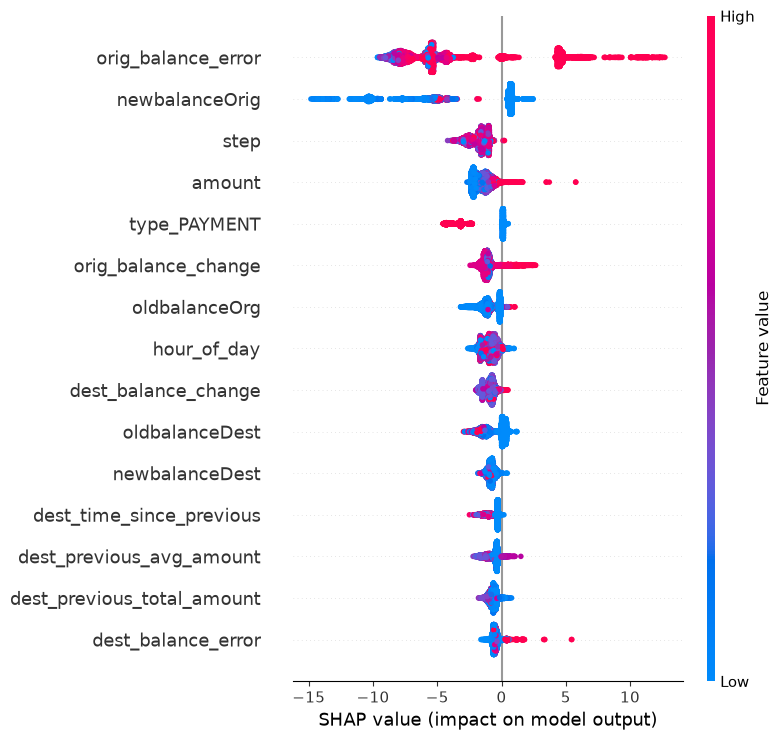

In [62]:
# ============================================================
# SHAP GLOBAL EXPLAINABILITY
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

print("Preparing SHAP analysis...")

# Sample the test set for efficient SHAP computation
sample_size = min(10_000, len(X_test))

X_shap = X_test.sample(
    n=sample_size,
    random_state=42
)

print(f"SHAP sample shape: {X_shap.shape}")

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated.")
print("Shape:", shap_values.shape)


# ============================================================
# GLOBAL FEATURE IMPORTANCE
# ============================================================

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values("Mean_Abs_SHAP", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("GLOBAL SHAP FEATURE IMPORTANCE")
print("=" * 70)

print(shap_importance.to_string(index=False))


# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=15,
    show=False
)

plt.tight_layout()
plt.show()

TRANSACTION EXPLANATION

Transaction index: 6283804

Actual class:
1

Predicted fraud probability:
1.0

Transaction features:
amount                             2333929.91
dest_balance_change                      0.00
dest_balance_error                 2333929.91
dest_previous_avg_amount                 0.00
dest_previous_total_amount               0.00
dest_previous_transaction_count          0.00
dest_time_since_previous                -1.00
hour_of_day                              9.00
isFlaggedFraud                           0.00
newbalanceDest                           0.00
newbalanceOrig                           0.00
oldbalanceDest                           0.00
oldbalanceOrg                      2333929.91
orig_balance_change                2333929.91
orig_balance_error                       0.00
orig_previous_avg_amount                 0.00
orig_previous_total_amount               0.00
orig_previous_transaction_count          0.00
orig_time_since_previous                -1.00


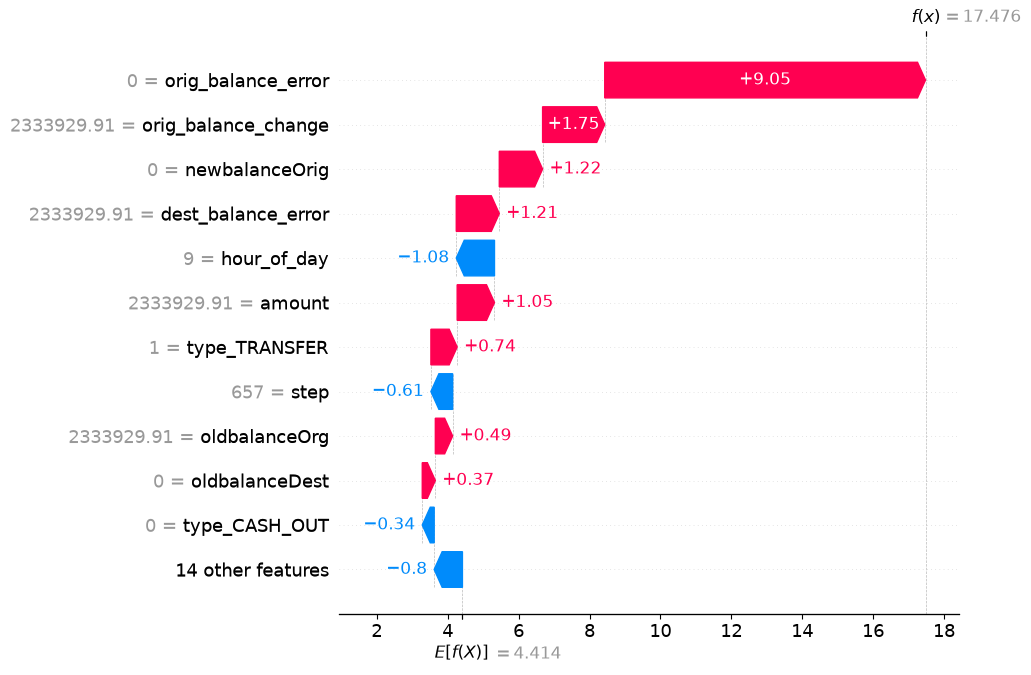

In [64]:
# ============================================================
# INDIVIDUAL FRAUD EXPLANATION
# ============================================================

# Find a fraudulent transaction in the SHAP sample
fraud_indices = X_shap.index[y_test.loc[X_shap.index] == 1]

# Select the first fraud transaction
fraud_idx = fraud_indices[0]

# Position of this transaction inside X_shap
fraud_position = X_shap.index.get_loc(fraud_idx)

print("=" * 70)
print("TRANSACTION EXPLANATION")
print("=" * 70)

print(f"\nTransaction index: {fraud_idx}")

print("\nActual class:")
print(y_test.loc[fraud_idx])

print("\nPredicted fraud probability:")
print(y_test_proba[X_test.index.get_loc(fraud_idx)])

print("\nTransaction features:")
print(
    X_test.loc[fraud_idx]
    .sort_index()
)


# ============================================================
# SHAP CONTRIBUTIONS
# ============================================================

transaction_shap = pd.DataFrame({
    "Feature": X_shap.columns,
    "Feature_Value": X_shap.iloc[fraud_position].values,
    "SHAP_Value": shap_values[fraud_position]
})

transaction_shap["Absolute_SHAP"] = (
    transaction_shap["SHAP_Value"].abs()
)

transaction_shap = (
    transaction_shap
    .sort_values("Absolute_SHAP", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("TOP FEATURES DRIVING THIS PREDICTION")
print("=" * 70)

print(
    transaction_shap.head(10).to_string(index=False)
)


# ============================================================
# WATERFALL PLOT
# ============================================================

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[fraud_position],
        base_values=explainer.expected_value,
        data=X_shap.iloc[fraud_position].values,
        feature_names=X_shap.columns
    ),
    max_display=12
)

In [65]:
# ============================================================
# TEMPORAL ROBUSTNESS CHECK
# ============================================================

test_results = X_test.copy()

test_results["actual"] = y_test
test_results["prediction"] = y_test_proba

# Create time buckets
test_results["time_bucket"] = pd.qcut(
    test_results["step"],
    q=5,
    duplicates="drop"
)

temporal_results = []

for bucket, group in test_results.groupby(
    "time_bucket",
    observed=True
):
    from sklearn.metrics import (
        average_precision_score,
        precision_score,
        recall_score,
        f1_score
    )

    y_true = group["actual"]
    y_prob = group["prediction"]
    y_pred = (y_prob >= 0.05).astype(int)

    temporal_results.append({
        "Time Period": str(bucket),
        "Transactions": len(group),
        "Fraud": int(y_true.sum()),
        "Fraud Rate (%)": y_true.mean() * 100,
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_true, y_pred, zero_division=0
        )
    })

temporal_results = pd.DataFrame(temporal_results)

print("=" * 90)
print("TEMPORAL ROBUSTNESS CHECK")
print("=" * 90)

print(
    temporal_results.to_string(index=False)
)

TEMPORAL ROBUSTNESS CHECK
     Time Period  Transactions  Fraud  Fraud Rate (%)  PR-AUC  Precision  Recall  F1
(631.999, 661.0]         18057    344        1.905078     1.0        1.0     1.0 1.0
  (661.0, 686.0]         21731    250        1.150430     1.0        1.0     1.0 1.0
  (686.0, 688.0]         15925     16        0.100471     1.0        1.0     1.0 1.0
  (688.0, 692.0]         16693     58        0.347451     1.0        1.0     1.0 1.0
  (692.0, 743.0]         17060    584        3.423212     1.0        1.0     1.0 1.0


In [66]:
# ============================================================
# REAL-TIME FEATURE AVAILABILITY AUDIT
# ============================================================

feature_audit = {
    # Available when the transaction request arrives
    "step": "SAFE",
    "type": "SAFE",
    "amount": "SAFE",
    "oldbalanceOrg": "SAFE",
    "oldbalanceDest": "SAFE",

    # Calculated from the current transaction/balances
    "newbalanceOrig": "CURRENT_TRANSACTION",
    "newbalanceDest": "CURRENT_TRANSACTION",
    "orig_balance_change": "CURRENT_TRANSACTION",
    "dest_balance_change": "CURRENT_TRANSACTION",
    "orig_balance_error": "CURRENT_TRANSACTION",
    "dest_balance_error": "CURRENT_TRANSACTION",

    # Time-derived
    "hour_of_day": "SAFE",

    # Historical behavioral features
    "orig_previous_transaction_count": "HISTORICAL",
    "orig_previous_total_amount": "HISTORICAL",
    "orig_previous_avg_amount": "HISTORICAL",
    "dest_previous_transaction_count": "HISTORICAL",
    "dest_previous_total_amount": "HISTORICAL",
    "dest_previous_avg_amount": "HISTORICAL",
    "orig_time_since_previous": "HISTORICAL",
    "dest_time_since_previous": "HISTORICAL",

    # Ratios based on current transaction/balance information
    "amount_to_orig_balance": "CURRENT_TRANSACTION",
    "amount_to_dest_balance": "CURRENT_TRANSACTION",
    "orig_balance_change_ratio": "CURRENT_TRANSACTION",
    "dest_balance_change_ratio": "CURRENT_TRANSACTION",

    # Transaction type encoding
    "type_CASH_IN": "SAFE",
    "type_CASH_OUT": "SAFE",
    "type_DEBIT": "SAFE",
    "type_PAYMENT": "SAFE",
    "type_TRANSFER": "SAFE",
}

audit_df = pd.DataFrame(
    feature_audit.items(),
    columns=["Feature", "Availability"]
)

print("=" * 75)
print("REAL-TIME FEATURE AVAILABILITY AUDIT")
print("=" * 75)

print(audit_df.to_string(index=False))

print("\n" + "=" * 75)
print("SUMMARY")
print("=" * 75)

print(
    audit_df["Availability"]
    .value_counts()
    .to_string()
)

print("\n" + "=" * 75)
print("FEATURES BY CATEGORY")
print("=" * 75)

for category in audit_df["Availability"].unique():
    print(f"\n[{category}]")
    for feature in audit_df.loc[
        audit_df["Availability"] == category,
        "Feature"
    ]:
        print(f"  - {feature}")

REAL-TIME FEATURE AVAILABILITY AUDIT
                        Feature        Availability
                           step                SAFE
                           type                SAFE
                         amount                SAFE
                  oldbalanceOrg                SAFE
                 oldbalanceDest                SAFE
                 newbalanceOrig CURRENT_TRANSACTION
                 newbalanceDest CURRENT_TRANSACTION
            orig_balance_change CURRENT_TRANSACTION
            dest_balance_change CURRENT_TRANSACTION
             orig_balance_error CURRENT_TRANSACTION
             dest_balance_error CURRENT_TRANSACTION
                    hour_of_day                SAFE
orig_previous_transaction_count          HISTORICAL
     orig_previous_total_amount          HISTORICAL
       orig_previous_avg_amount          HISTORICAL
dest_previous_transaction_count          HISTORICAL
     dest_previous_total_amount          HISTORICAL
       dest_previous_avg_am